# Prophet 时序预测——设备产量

使用 Facebook Prophet 对周度设备产量进行预测。

数据：`data/production_weekly.csv`（55行，周度，2025-03-03 ~ 2026-03-09）

训练集：前 80%（44行）；测试集：后 20%（11行）；预测步长：11周

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from prophet import Prophet

plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

raw = pd.read_csv('data/production_weekly.csv')
raw['日期'] = pd.to_datetime(raw['日期'])
df = raw.rename(columns={'日期': 'ds', '产量': 'y'})[['ds', 'y']]
print(f'数据行数: {len(df)}，时间范围: {df["ds"].min().date()} ~ {df["ds"].max().date()}')
df.tail(10)

数据行数: 54，时间范围: 2025-03-03 ~ 2026-03-09


,ds,y
44,2026-01-05,126072
45,2026-01-12,129120
46,2026-01-19,127088
47,2026-01-26,112912
48,2026-02-02,69888
49,2026-02-09,44912
50,2026-02-16,44912
51,2026-02-23,54520
52,2026-03-02,139064
53,2026-03-09,84480


训练集: 43 行  (2025-03-03 ~ 2025-12-22)
测试集: 11 行  (2025-12-29 ~ 2026-03-09)
预测步长: 11 周


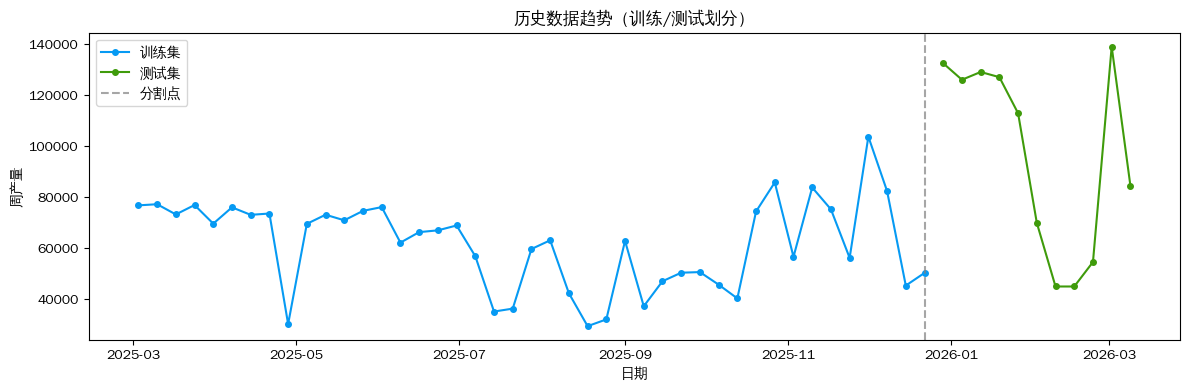

In [13]:
# 按 80/20 划分训练集和测试集
TRAIN_RATIO = 0.8
split_idx = int(len(df) * TRAIN_RATIO)
train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()
PRED_LEN = len(test_df)

print(f'训练集: {len(train_df)} 行  ({train_df["ds"].min().date()} ~ {train_df["ds"].max().date()})')
print(f'测试集: {len(test_df)} 行  ({test_df["ds"].min().date()} ~ {test_df["ds"].max().date()})')
print(f'预测步长: {PRED_LEN} 周')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_df['ds'], train_df['y'], marker='o', markersize=4, color='xkcd:azure', label='训练集')
ax.plot(test_df['ds'],  test_df['y'],  marker='o', markersize=4, color='xkcd:grass green', label='测试集')
ax.axvline(x=train_df['ds'].iloc[-1], color='gray', linestyle='--', alpha=0.7, label='分割点')
ax.set_title('历史数据趋势（训练/测试划分）')
ax.set_xlabel('日期')
ax.set_ylabel('周产量')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# 周度产量数据：三类内置季节性全部关闭。
#   - weekly_seasonality=False：数据本身即周度，每行代表整周，
#     不存在"周内各天"规律，强开会导致 Fourier 系数数值爆炸。
#   - daily_seasonality=False：同理，无日内规律。
#   - yearly_seasonality=False：训练集仅覆盖 2025-03 ~ 2025-12，
#     不足一整年。Prophet 年度季节性为 365.25 天周期 Fourier 级数，
#     在训练集看不到 1-2 月的情况下，强开会对这两月做严重错误外推
#     （预测 1 月产量高达 160 万，实际仅 12 万，误差 12 倍以上）。
#     如果将来积累到 ≥2 年完整数据，可以重新开启并加入春节假期特征。
m = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
)
m.fit(train_df)
print('模型训练完成')

10:22:12 - cmdstanpy - INFO - Chain [1] start processing
10:22:12 - cmdstanpy - INFO - Chain [1] done processing


模型训练完成


In [15]:
# 向未来延伸 PRED_LEN 周
# 注意：freq='W' 默认锚定周日（W-SUN），若训练集末尾是周一，
# 则预测日期会整体偏移 1 天，导致与测试集对比时日期错位。
# 改用 freq='7D' 以"固定7天步长"延续训练集的星期几对齐。
future = m.make_future_dataframe(periods=PRED_LEN, freq='7D')
forecast = m.predict(future)
forecast_test = forecast.tail(PRED_LEN)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].reset_index(drop=True)
print(f'预测期: {forecast_test["ds"].iloc[0].date()} ~ {forecast_test["ds"].iloc[-1].date()}')
forecast_test

预测期: 2025-12-29 ~ 2026-03-09


,ds,yhat,yhat_lower,yhat_upper
0,2025-12-29,56495.493968,35853.893514,77703.057082
1,2026-01-05,56255.758798,34595.280322,77923.354258
2,2026-01-12,56016.023627,33425.543611,78419.342353
3,2026-01-19,55776.288457,33994.797112,76800.527707
4,2026-01-26,55536.553287,33069.855935,76958.407792
5,2026-02-02,55296.818116,33046.573039,75296.512524
6,2026-02-09,55057.082946,33280.903132,75953.836156
7,2026-02-16,54817.347776,33069.019369,74170.816826
8,2026-02-23,54577.612606,33116.665050,77208.859021
9,2026-03-02,54337.877435,33073.761370,76937.612942


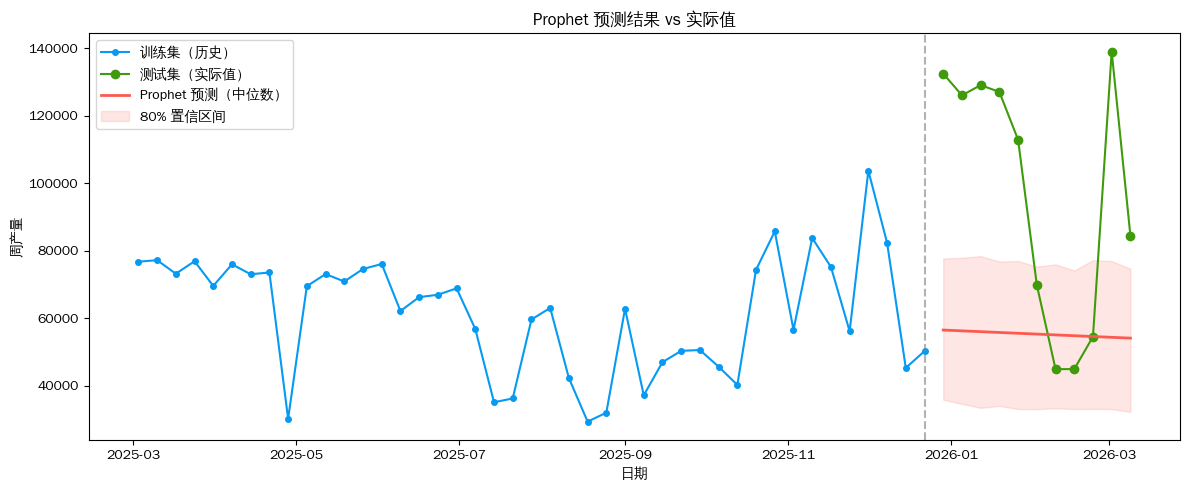

In [16]:
# 绘制预测结果 vs 实际值
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_df['ds'], train_df['y'],
        color='xkcd:azure', marker='o', markersize=4, label='训练集（历史）')
ax.plot(test_df['ds'],  test_df['y'],
        color='xkcd:grass green', marker='o', markersize=6, label='测试集（实际值）')
ax.plot(forecast_test['ds'], forecast_test['yhat'],
        color='xkcd:coral', linewidth=2, label='Prophet 预测（中位数）')
ax.fill_between(forecast_test['ds'],
                forecast_test['yhat_lower'], forecast_test['yhat_upper'],
                color='xkcd:coral', alpha=0.15, label='80% 置信区间')
ax.axvline(x=train_df['ds'].iloc[-1], color='gray', linestyle='--', alpha=0.6)
ax.set_title('Prophet 预测结果 vs 实际值')
ax.set_xlabel('日期')
ax.set_ylabel('周产量')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# 误差指标：MAE、RMSE、MAPE
y_true = test_df['y'].values
y_pred = forecast_test['yhat'].values

mae  = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print('─' * 35)
print(f'  MAE  (平均绝对误差):      {mae:.1f}')
print(f'  RMSE (均方根误差):        {rmse:.1f}')
print(f'  MAPE (平均绝对百分误差):  {mape:.2f}%')
print('─' * 35)

───────────────────────────────────
  MAE  (平均绝对误差):      45222.5
  RMSE (均方根误差):        54682.8
  MAPE (平均绝对百分误差):  39.89%
───────────────────────────────────
